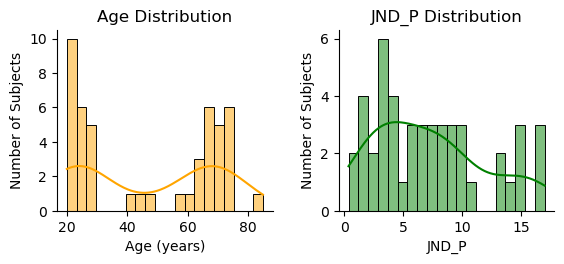

In [1]:
import pandas as pd
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
import numpy as np
import os
import matplotlib.pyplot as plt

pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
os.chdir(pathcsv)

# Charger le fichier CC (exemple : CC1)
cc_data = pd.read_csv('CC_6_FA_03022026_AllSubjects.csv')
behavior_data = pd.read_csv('Subject_preproc_03022026_AllSubjects.csv')
behavior_data

# Ajouter la colonne 'age'
cc_data['age'] = behavior_data['age']
cc_data['JND'] = behavior_data['JND_P']

 # target var

import seaborn as sns

age = behavior_data['age'].values
jnd = behavior_data['JND_P'].values

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
plt.tight_layout(pad=2.0)
plt.show()


selected_features_corr: ['82', '15', '81', '16', '83', '84', '80', '85', '76', '79', '78', '77', '87', '18', '14', '75', '86', '89', '88', '13', '90', '0', '1', '17', '12', '2', '11', '3', '10', '91', '74', '69', '19', '70', '71', '4', '8', '92', '20', '73', '51', '50', '5', '52', '68', '49', '6', '7', '21', '72', '9', '67', '53', '24', '93', '41', '66', '40', '28', '27', '54', '26', '22', '42', '48', '65', '23', '39', '25', '64', '55', '56', '43', '44', '63', '57', '29', '38', '62', '31', '94', '30', '58', '37', '61', '59', '60', '36', '32']
selected_features_lasso: Index(['0', '1', '3', '12', '15', '18', '26', '29', '35', '36', '37', '48',
       '52', '63', '70', '72', '73', '75', '76', '81', '82', '90', '93', '95',
       '97'],
      dtype='object')
Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Linear Regression : R² moyen = -0.255 ± 0.372
Random Forest : R² moyen = 0.508 ± 0.163
SVM : R² moyen = -0.201 ± 0.541


IndexError: index 32 is out of bounds for axis 0 with size 25

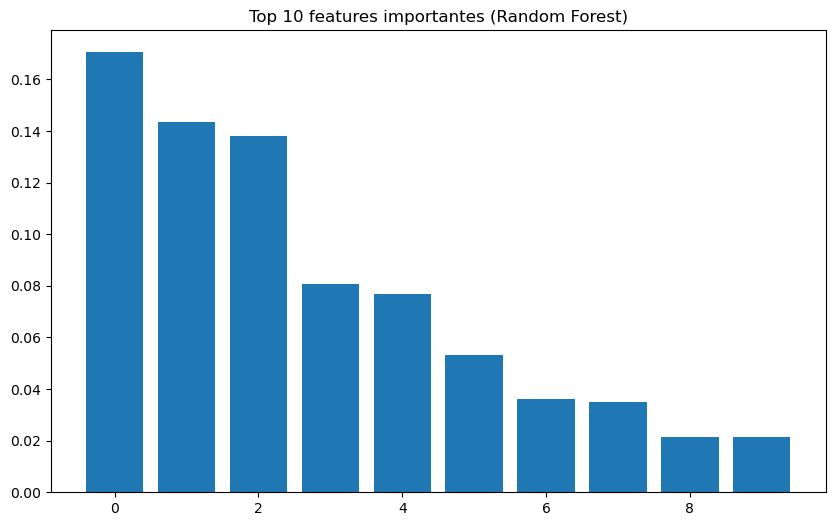

In [4]:

# Séparer les features (X) et la cible (y)
X = cc_data.iloc[:, :98]
y = cc_data['JND']
y = cc_data['age']


# Calculer les corrélations avec l'âge
corr = X.corrwith(y).abs().sort_values(ascending=False)

# Sélectionner les features avec une corrélation > 0.4 (par exemple)
selected_features_corr = corr[corr > 0.4].index.tolist()
X_corr = X[selected_features_corr]
print("selected_features_corr:", selected_features_corr)
# Utiliser Lasso pour sélectionner les features
lasso = Lasso(alpha=0.01)
sfm = SelectFromModel(lasso)
sfm.fit(X, y)
selected_features_lasso = X.columns[sfm.get_support()]
X_lasso = X[selected_features_lasso]
print("selected_features_lasso:", selected_features_lasso)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVM': make_pipeline(StandardScaler(), SVR(kernel='rbf'))
}

# Définir la grille de paramètres
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Initialiser GridSearchCV
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_corr, y)

# Meilleur modèle
best_rf = grid_search.best_estimator_
print("Meilleurs paramètres :", grid_search.best_params_)

# Évaluer chaque modèle avec validation croisée
for name, model in models.items():
    scores = cross_val_score(model, X_corr, y, cv=5, scoring='r2')
    print(f"{name} : R² moyen = {np.mean(scores):.3f} ± {np.std(scores):.3f}")

import matplotlib.pyplot as plt

# Extraire l'importance des features
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
indices

# Tracer les 10 features les plus importantes
plt.figure(figsize=(10, 6))
plt.title("Top 10 features importantes (Random Forest)")
plt.bar(range(10), importances[indices][:10], align='center')
plt.xticks(range(10), X_lasso.columns[indices][:10])
plt.tight_layout()
plt.show()
